In [1]:
# This notebook is a minimal, end-to-end L2O study example on quadratic tasks.
import matplotlib.pyplot as plt
import torch

In [2]:
# Import one handcrafted baseline optimizer (Adam).
from optimization import OptimizerAdam

In [3]:
# Import a learned optimizer architecture used for meta-training.
from l2o.models import OptimizerNeuralCoordinatewiseGradEnc

In [4]:
# Import the minimal quadratic data/training utilities for the L2O loop.
from l2o import train_optimizer, tune_adam_learning_rate
from problems.quadratic import (
    RandomQuadraticFunctionsDataset,
    collate_quadratic_batch,
    make_aligned_quadratic_problem,
    distance_to_solution,
)

In [5]:
# Ill-conditioned quadratics; align with `scripts/train_quadratic_l2o.py` and use the same
# inner unroll for meta-training and evaluation (see next cell - mismatched unroll makes L2O look worse than Adam).
torch.manual_seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

x_dim = 8
y_dim = 8

inner_steps = 64
meta_epochs = 100

dataset = RandomQuadraticFunctionsDataset(
    size=512,
    x_dim=x_dim,
    y_dim=y_dim,
    device="cpu",
    seed=1,
    noise_std=0.1,
    ill_conditioned=False,
    condition_number=1e3,
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_quadratic_batch,
    num_workers=0,
)

In [6]:
# Same recipe as train_quadratic_l2o.py: full unroll, no grad-scale noise (ill-conditioned tasks).
opt_learned = OptimizerNeuralCoordinatewiseGradEnc(
    x_dim, 
    hidden_size=64, 
    max_unroll_steps=float(inner_steps),
).to(device)

opt_learned = train_optimizer(
    opt_learned,
    dataloader,
    device,
    n_epochs=meta_epochs,
    meta_lr=0.01,
    n_outer_chunks=1,
    max_unroll=inner_steps,
    fixed_unroll=inner_steps,
    grad_scale_augment=False,
    meta_weight_decay=0.0,
    extra_init_noise_scale=1.0,
)

Epoch: 100%|██████████| 100/100 [03:53<00:00,  2.33s/it]


In [7]:
inner_steps_eval = 128

In [8]:
# Held-out task
optimizee, _ = make_aligned_quadratic_problem(
    y_dim, 
    x_dim, 
    device, 
    seed=42, 
    noise_std=0.1, 
    ill_conditioned=False,
    condition_number=1e3,
)
optimizee = optimizee.to(device)
torch.manual_seed(123)
x0 = torch.randn(1, x_dim, device=device)

opt_learned.eval()
opt_learned.reset()
x = x0.clone()
loss_l2o = []
path_l2o = [x[0].detach().cpu()]
for step in range(inner_steps_eval):
    loss_t, grad = optimizee.loss_and_grad(x)
    delta = opt_learned(grad.detach(), loss=loss_t, step=torch.tensor(float(step), device=device))
    x = x + delta
    loss_l2o.append(optimizee(x)[0].item())
    path_l2o.append(x[0].detach().cpu())

In [9]:
# Tune Adam on the same task with the same step budget as L2O.
best_lr = tune_adam_learning_rate(
    [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 0.1],
    optimizee,
    x0,
    n_steps=inner_steps_eval,
    device=device,
    eps=1e-8,
)
opt_adam = OptimizerAdam(x_dim, lr=best_lr, beta1=0.9, beta2=0.999, eps=1e-8).to(device)

x = x0.clone()
loss_adam = []
path_adam = [x[0].detach().cpu()]

for _ in range(inner_steps_eval):
    _, grad = optimizee.loss_and_grad(x)
    x = x + opt_adam(grad.detach())
    loss_adam.append(optimizee(x)[0].item())
    path_adam.append(x[0].detach().cpu())

Best Adam lr: 0.1
Final loss Adam=0.051314, L2O=0.013012


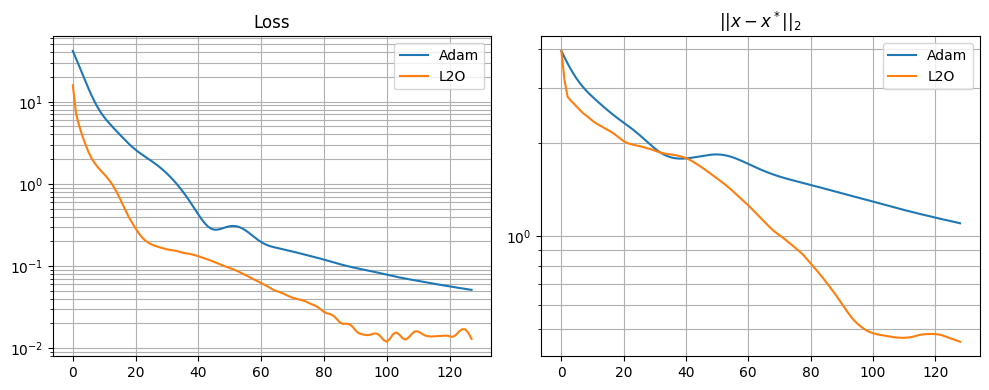

In [11]:
# Plot objective and distance-to-solution trajectories to compare behaviors.
b_vec = optimizee.b if optimizee.b.dim() == 1 else optimizee.b[0]
x_opt = torch.linalg.lstsq(optimizee.A[0], b_vec).solution

d_l2o = distance_to_solution(path_l2o, x_opt)
d_adam = distance_to_solution(path_adam, x_opt)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].semilogy(loss_adam, label="Adam")
ax[0].semilogy(loss_l2o, label="L2O")
ax[0].set_title("Loss")
ax[0].grid(True, which="both")
ax[0].legend()

ax[1].semilogy(d_adam, label="Adam")
ax[1].semilogy(d_l2o, label="L2O")
ax[1].set_title(r"$||x - x^*||_2$")
ax[1].grid(True, which="both")
ax[1].legend()

plt.tight_layout()
print(f"Best Adam lr: {best_lr:.3g}")
print(f"Final loss Adam={loss_adam[-1]:.6f}, L2O={loss_l2o[-1]:.6f}")